In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
ticker = "AAPL"

print(f"Downloading data for {ticker}...")

data = yf.download(
    ticker,
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=True
)

[*********************100%***********************]  1 of 1 completed


In [4]:
if data.empty:
    print("Error: No stock data found.")
    exit()

print("\nFirst 5 rows:")
print(data.head())


First 5 rows:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.271538  72.331694  71.029915  71.282568  135480400
2020-01-03  71.568916  72.326882  71.345137  71.501542  146322800
2020-01-06  72.139175  72.177676  70.442777  70.693028  118387200
2020-01-07  71.799911  72.403874  71.580942  72.148812  108872000
2020-01-08  72.954941  73.255721  71.503975  71.503975  132079200


In [5]:
data = data[["Close"]].copy()      # Keep only Close price

In [6]:
data.dropna(inplace=True)        # Remove missing values

In [7]:
data.reset_index(inplace=True)       # Convert index into column

print("\nCleaned data:")
print(data.head())


Cleaned data:
Price        Date      Close
Ticker                  AAPL
0      2020-01-02  72.271538
1      2020-01-03  71.568916
2      2020-01-06  72.139175
3      2020-01-07  71.799911
4      2020-01-08  72.954941


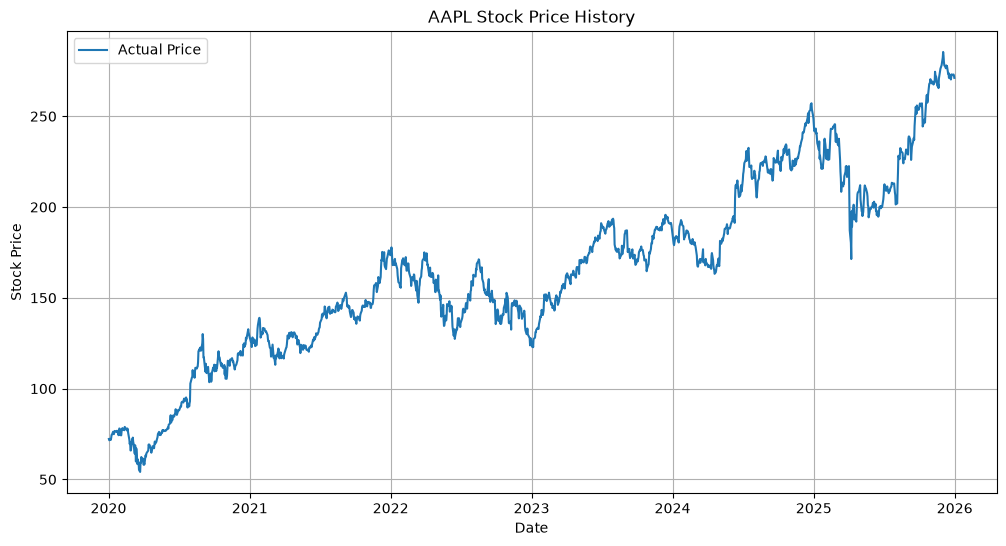

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(
    data["Date"],
    data["Close"],
    label="Actual Price"
)

plt.title(f"{ticker} Stock Price History")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.show()


In [9]:

data["Days"] = (
    data["Date"] - data["Date"].min()      # Converting date into numerical values
).dt.days

X = data[["Days"]]
y = data["Close"]


In [10]:
split_index = int(len(data) * 0.8)        # Use chronological split

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [11]:
model = LinearRegression()         #linearregression model training

model.fit(X_train, y_train)

print("\nModel trained successfully!")


Model trained successfully!


In [12]:
y_pred = model.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("\n====== MODEL PERFORMANCE =======")

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")


====== MODEL PERFORMANCE =======
Mean Absolute Error: 21.00
Root Mean Squared Error: 23.83
R2 Score: 0.0607


Visualized  actual price Vs predicted price

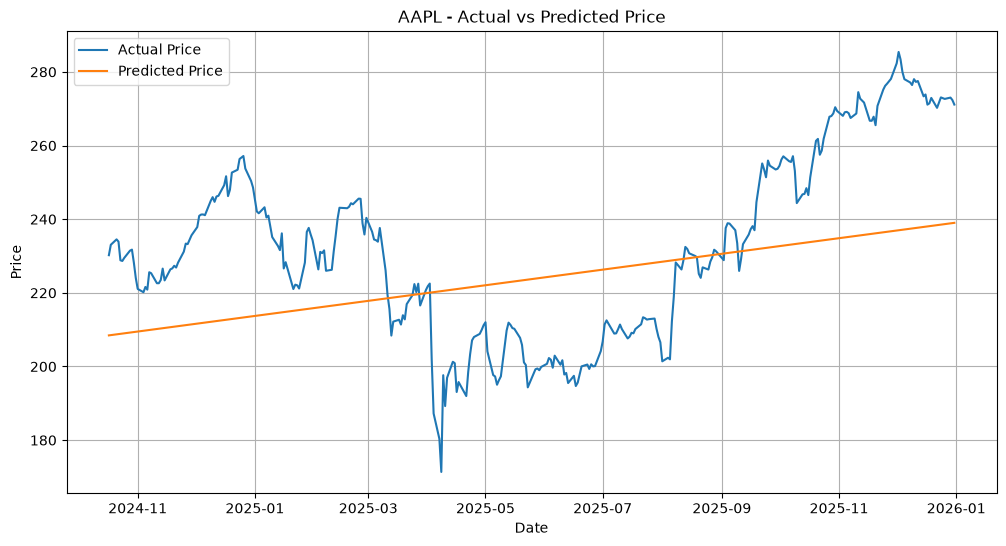

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(
    data["Date"].iloc[split_index:],
    y_test,
    label="Actual Price"
)

plt.plot(
    data["Date"].iloc[split_index:],
    y_pred,
    label="Predicted Price"
)

plt.title(f"{ticker} - Actual vs Predicted Price")

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(True)

plt.show()



In [17]:
future_days = 30           #predicting future price

last_day = data["Days"].iloc[-1]

future_X = np.array([
    last_day + i
    for i in range(1, future_days + 1)
]).reshape(-1, 1)

future_predictions = model.predict(future_X)

In [ ]:
future_dates = pd.date_range(       #create future dates
    start=data["Date"].iloc[-1] + pd.Timedelta(days=1),
    periods=future_days
)

future_data = pd.DataFrame({
    "Date": future_dates,
    "Predicted Price": future_predictions.flatten()
})


In [22]:
print("\n========== FUTURE PRICE PREDICTION ==========")

print(future_data)



========== FUTURE PRICE PREDICTION ==========
         Date  Predicted Price
0  2026-01-01       239.076976
1  2026-01-02       239.146424
2  2026-01-03       239.215873
3  2026-01-04       239.285321
4  2026-01-05       239.354770
5  2026-01-06       239.424218
6  2026-01-07       239.493667
7  2026-01-08       239.563115
8  2026-01-09       239.632564
9  2026-01-10       239.702012
10 2026-01-11       239.771461
11 2026-01-12       239.840909
12 2026-01-13       239.910357
13 2026-01-14       239.979806
14 2026-01-15       240.049254
15 2026-01-16       240.118703
16 2026-01-17       240.188151
17 2026-01-18       240.257600
18 2026-01-19       240.327048
19 2026-01-20       240.396497
20 2026-01-21       240.465945
21 2026-01-22       240.535394
22 2026-01-23       240.604842
23 2026-01-24       240.674291
24 2026-01-25       240.743739
25 2026-01-26       240.813187
26 2026-01-27       240.882636
27 2026-01-28       240.952084
28 2026-01-29       241.021533
29 2026-01-30       241

Visualization of future prediction

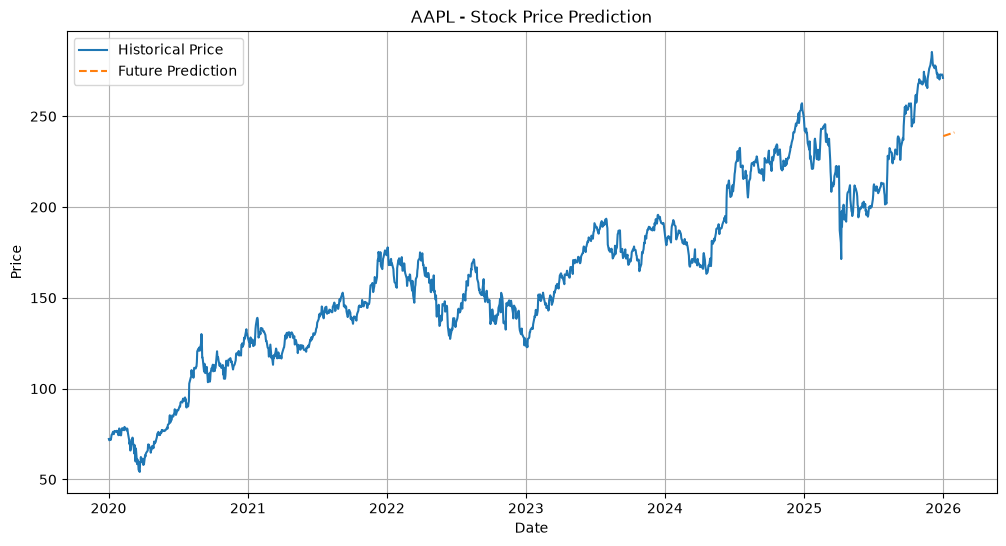

In [23]:
plt.figure(figsize=(12, 6))

plt.plot(
    data["Date"],
    data["Close"],
    label="Historical Price"
)

plt.plot(
    future_data["Date"],
    future_data["Predicted Price"],
    label="Future Prediction",
    linestyle="--"
)

plt.title(
    f"{ticker} - Stock Price Prediction"
)

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(True)

plt.show()